# Projeto de precificação do valor cobrado para entrega de esculturas

![](https://github.com/Mirlaa/regressao-arvores/blob/main/imagens-projeto/imagem-do-projeto-inicio.png?raw=true)

#  Trabalhando com os dados

In [125]:
url = 'Dados/entregas.csv'
url_teste = 'Dados/teste_entregas.csv'


In [126]:
import pandas as pd
import numpy as np

In [127]:
dados = pd.read_csv(url)
dados

,id_cliente,nome_artista,reputacao_artista,altura,largura,peso,material,preco_escultura,preco_base_envio,internacional,envio_expresso,instalacao_incluida,transporte,fragil,pedido_extra_cliente,localizacao_remota,data_agendada,data_entrega,custo
0,e9dff114-bc2b-47e9-9f5c-669e32ad9bbe,Billy Jenkins,0.26000,5.1816,1.8288,1872.427776,Latão,73027.5,85.4175,Sim,Sim,Não,Aéreo,Não,Sim,Não,07/06/19,03/06/19,1487.2725
1,ba3b707f-b123-4eec-93f4-1fbebfe72b68,Jean Bryant,0.28000,0.9144,0.9144,27.669112,Latão,35857.5,78.7500,Não,Não,Não,Rodoviário,Não,Sim,Não,06/03/21,05/03/21,839.7900
2,c4212086-3e22-489e-bc2e-0d5092ef0526,Laura Miller,0.07000,2.4384,1.5240,107.501304,Argila,26040.0,111.1950,Não,Não,Não,Rodoviário,Sim,Sim,Sim,09/03/19,08/03/19,810.0225
3,fec1bee9-44cf-498f-a849-5e5e2cab062b,Robert Chaires,0.12000,2.7432,2.4384,1407.042384,Alumínio,30502.5,85.6275,Não,Não,Não,Não especificado,Não,Não,Sim,24/05/19,20/05/19,846.0900
4,f9f2ed8c-7f56-4e69-a80e-cb01d0a711da,Rosalyn Krol,0.15000,5.1816,1.8288,146.963808,Alumínio,16695.0,62.6850,Sim,Sim,Sim,Aéreo,Não,Sim,Não,18/12/20,14/12/20,835.9575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,d692e37c-8047-468e-ba60-89b977158662,Phil Wilson,0.93000,6.0960,2.4384,294.381208,Alumínio,25462.5,130.0950,Sim,Não,Sim,Aquaviário,Não,Sim,Não,23/03/19,27/03/19,3923.9550
4458,2671f714-e85d-46c9-a53a-7bca8d61a2cb,Berry Simmons,0.67000,3.9624,2.4384,215.456200,Alumínio,19162.5,67.8825,Sim,Não,Sim,Rodoviário,Não,Sim,Não,28/10/22,27/10/22,1546.7550
4459,e1004685-9047-4f34-9103-57d900716936,William Curry,0.46185,3.9624,2.4384,69.853168,Madeira,27982.5,68.2500,Não,Sim,Não,Aéreo,Não,Não,Não,16/03/21,16/03/21,916.4925
4460,a380ff88-2c96-4d70-919a-af0bc8caeed7,Karen Bayles,0.45000,6.0960,8.5344,4921.926792,Alumínio,161857.5,355.4250,Não,Não,Sim,Rodoviário,Não,Sim,Não,19/04/20,21/04/20,5653.4625


Dicionário de dados:

| Nome da Coluna       | Descrição                                                      |
|----------------------|----------------------------------------------------------------|
| id_cliente        | Representa o número de identificação único dos clientes        |
| nome_artista      | Representa o nome do artista                                   |
| reputacao_artista | Representa a reputação de um artista no mercado (quanto maior o valor da reputação, maior a reputação do artista no mercado) |
| altura               | Representa a altura da escultura em metros                     |
| largura              | Representa a largura da escultura em metros                     |
| peso                 | Representa o peso da escultura em quilos                       |
| material             | Representa o material do qual a escultura é feita              |
| preco_escultura   | Representa o preço da escultura         |
| preco_base_envio  | Representa o preço base para o envio de uma escultura          |
| internacional        | Indica se o envio é internacional                              |
| envio_expresso       | Indica se o envio foi no modo expresso (rápido)    |
| instalacao_incluida  | Indica se a instalação estava incluída na compra da escultura  |
| transporte           | Representa o modo de transporte do pedido                      |
| fragil               | Indica se o pedido é frágil                                    |
| pedido_extra_cliente | Representa se o cliente deixou detalhes a mais para entrega     |
| data_agendada        | Representa a data de previsão de entrega        |
| data_entrega      | Representa a data de entrega do pedido          |
| custo                | Representa o custo do envio do pedido      |

In [128]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            4462 non-null   str    
 1   nome_artista          4462 non-null   str    
 2   reputacao_artista     4462 non-null   float64
 3   altura                4462 non-null   float64
 4   largura               4462 non-null   float64
 5   peso                  4462 non-null   float64
 6   material              4462 non-null   str    
 7   preco_escultura       4462 non-null   float64
 8   preco_base_envio      4462 non-null   float64
 9   internacional         4462 non-null   str    
 10  envio_expresso        4462 non-null   str    
 11  instalacao_incluida   4462 non-null   str    
 12  transporte            4462 non-null   str    
 13  fragil                4462 non-null   str    
 14  pedido_extra_cliente  4462 non-null   str    
 15  localizacao_remota    4462 non-n

**ENTENDENDO AS COLUNAS**

**Dado numérico:**
- `'reputacao_artista'`, `'altura'`, `'largura'`, `'peso'`, `'preco_escultura'`, `'preco_base_envio'`.

**Categóricas:**

- `'id_cliente'`, `'nome_artista'`, `'material'`, `'internacional'`, `'envio_expresso'`, `'instalacao_incluida'`, `'transporte'`, `'fragil'`, `'pedido_extra_cliente'`, `localizacao_remota`.

**Datas:**

- `'data_agendada'`, `'data_entrega'`.

**Alvo:**
- `'custo'`.

In [129]:
df = dados.copy()

In [130]:
df['data_agendada'] = pd.to_datetime(df['data_agendada'], format = '%d/%m/%y')
df['data_entrega'] = pd.to_datetime(df['data_entrega'], format='%d/%m/%y')

In [131]:
df['diferenca_dias_entrega'] = (df['data_entrega'] - df['data_agendada']).dt.days

In [132]:
df['data_agendada_dias'] = df['data_agendada'].dt.day
df['data_agendada_mes'] = df['data_agendada'].dt.month
df['data_agendada_ano'] = df['data_agendada'].dt.year

In [133]:
df['data_entrega_dias'] = df['data_entrega'].dt.day
df['data_entrega_mes'] = df['data_entrega'].dt.month
df['data_entrega_ano'] = df['data_entrega'].dt.year

In [134]:
df.drop(['data_agendada','data_entrega'], axis = 1, inplace = True)

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              4462 non-null   str    
 1   nome_artista            4462 non-null   str    
 2   reputacao_artista       4462 non-null   float64
 3   altura                  4462 non-null   float64
 4   largura                 4462 non-null   float64
 5   peso                    4462 non-null   float64
 6   material                4462 non-null   str    
 7   preco_escultura         4462 non-null   float64
 8   preco_base_envio        4462 non-null   float64
 9   internacional           4462 non-null   str    
 10  envio_expresso          4462 non-null   str    
 11  instalacao_incluida     4462 non-null   str    
 12  transporte              4462 non-null   str    
 13  fragil                  4462 non-null   str    
 14  pedido_extra_cliente    4462 non-null   str    
 15

In [136]:
colunas_categoricas = ['id_cliente', 'nome_artista', 'material', 'internacional', 'envio_expresso', 'instalacao_incluida',
                       'transporte', 'fragil', 'pedido_extra_cliente','localizacao_remota']

for column in colunas_categoricas:
    unique_values = df[column].unique()
    print(f"Valores únicos na coluna '{column}' \n {len(unique_values)} valores:")
    print(unique_values)
    print('=='*45)

Valores únicos na coluna 'id_cliente' 
 4462 valores:
<StringArray>
['e9dff114-bc2b-47e9-9f5c-669e32ad9bbe',
 'ba3b707f-b123-4eec-93f4-1fbebfe72b68',
 'c4212086-3e22-489e-bc2e-0d5092ef0526',
 'fec1bee9-44cf-498f-a849-5e5e2cab062b',
 'f9f2ed8c-7f56-4e69-a80e-cb01d0a711da',
 '4f77ce0e-6f48-463a-8ee2-3e8ed52e199d',
 '83221e08-cefd-4cf4-851b-97a44cfae73d',
 'cb2f7427-2ab0-43a6-9791-165fe583f511',
 'd2b76aa0-dc16-435e-bc8f-f12c7c751b1f',
 '915d1616-39c8-4e1d-bc5a-fd58f86bc26e',
 ...
 'dbc2998b-9735-4795-afc8-e1041b022f3b',
 '85b0c708-d7b1-4e66-b2a7-28c3db3d8631',
 'bb35df78-e5b5-45b4-9986-64ba4b3e0164',
 'ef28969e-5e38-45e7-b7d7-70aa8b2a1531',
 '18bbd4ee-e925-422b-bec7-7739ba61ac89',
 'd692e37c-8047-468e-ba60-89b977158662',
 '2671f714-e85d-46c9-a53a-7bca8d61a2cb',
 'e1004685-9047-4f34-9103-57d900716936',
 'a380ff88-2c96-4d70-919a-af0bc8caeed7',
 '26fea648-9cc1-4a2b-9458-0b2d35957803']
Length: 4462, dtype: str
Valores únicos na coluna 'nome_artista' 
 4441 valores:
<StringArray>
[    'Billy 

**ENTENDENDO AS COLUNAS TEXTUAIS**

**Categóricas:**

- *Valores binários*: `'internacional'`, `'envio_expresso'`, `'instalacao_incluida'`,  `'fragil'`, `'pedido_extra_cliente'`, `'localizacao_remota'`.
- *Várias Categorias*:`'material'`, `'transporte'`
- *Valores únicos*: `'id_cliente'`, `'nome_artista'`

In [137]:
categoricas = ['internacional', 'envio_expresso', 'instalacao_incluida', 'fragil', 'pedido_extra_cliente', 'localizacao_remota', 'material', 'transporte']

df = pd.get_dummies(df, columns = categoricas,
                    prefix = categoricas,
                    drop_first=True)

In [138]:
df.drop(['id_cliente', 'nome_artista'], axis = 1, inplace = True)

In [139]:
df

,reputacao_artista,altura,largura,peso,preco_escultura,preco_base_envio,custo,diferenca_dias_entrega,data_agendada_dias,data_agendada_mes,...,material_Argila,material_Bronze,material_Latão,material_Madeira,material_Mármore,material_Não especificado,material_Pedra,transporte_Aéreo,transporte_Não especificado,transporte_Rodoviário
0,0.26000,5.1816,1.8288,1872.427776,73027.5,85.4175,1487.2725,-4,7,6,...,False,False,True,False,False,False,False,True,False,False
1,0.28000,0.9144,0.9144,27.669112,35857.5,78.7500,839.7900,-1,6,3,...,False,False,True,False,False,False,False,False,False,True
2,0.07000,2.4384,1.5240,107.501304,26040.0,111.1950,810.0225,-1,9,3,...,True,False,False,False,False,False,False,False,False,True
3,0.12000,2.7432,2.4384,1407.042384,30502.5,85.6275,846.0900,-4,24,5,...,False,False,False,False,False,False,False,False,True,False
4,0.15000,5.1816,1.8288,146.963808,16695.0,62.6850,835.9575,-4,18,12,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,0.93000,6.0960,2.4384,294.381208,25462.5,130.0950,3923.9550,4,23,3,...,False,False,False,False,False,False,False,False,False,False
4458,0.67000,3.9624,2.4384,215.456200,19162.5,67.8825,1546.7550,-1,28,10,...,False,False,False,False,False,False,False,False,False,True
4459,0.46185,3.9624,2.4384,69.853168,27982.5,68.2500,916.4925,0,16,3,...,False,False,False,True,False,False,False,True,False,False
4460,0.45000,6.0960,8.5344,4921.926792,161857.5,355.4250,5653.4625,2,19,4,...,False,False,False,False,False,False,False,False,False,True


# Construindo Árvore de Regressão

In [140]:
from sklearn.model_selection import train_test_split

X = df.drop('custo',axis = 1)
y = df['custo']

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y, test_size = 0.2, random_state=45)

In [141]:
len(X_teste),len(X_treino)

(893, 3569)

In [142]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(random_state=45)
dtr.fit(X_treino,y_treino)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",45
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [143]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, dtr.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, dtr.predict(X_treino)))
print('RMSE:', root_mean_squared_error(y_treino, dtr.predict(X_treino)))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, dtr.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, dtr.predict(X_teste)))
print('RMSE:', root_mean_squared_error(y_teste, dtr.predict(X_teste)))


Métricas conjunto de treino:
R²: 1.0
MAE: 0.0
RMSE: 0.0


Métricas conjunto de teste:
R²: 0.653877834848489
MAE: 699.08312150056
RMSE: 1559.8538015690244


In [144]:
print(f"Número de nós: {dtr.tree_.node_count}")
print(f"Número de folhas: {dtr.tree_.n_leaves}")
print(f"Profundidade máxima: {dtr.tree_.max_depth}")

Número de nós: 7135
Número de folhas: 3568
Profundidade máxima: 30


In [145]:
dtr.feature_names_in_

array(['reputacao_artista', 'altura', 'largura', 'peso',
       'preco_escultura', 'preco_base_envio', 'diferenca_dias_entrega',
       'data_agendada_dias', 'data_agendada_mes', 'data_agendada_ano',
       'data_entrega_dias', 'data_entrega_mes', 'data_entrega_ano',
       'internacional_Sim', 'envio_expresso_Sim',
       'instalacao_incluida_Sim', 'fragil_Sim',
       'pedido_extra_cliente_Sim', 'localizacao_remota_Sim',
       'material_Argila', 'material_Bronze', 'material_Latão',
       'material_Madeira', 'material_Mármore',
       'material_Não especificado', 'material_Pedra', 'transporte_Aéreo',
       'transporte_Não especificado', 'transporte_Rodoviário'],
      dtype=object)

In [146]:
dtr.feature_importances_

array([2.94192440e-01, 4.19945455e-02, 3.86520763e-02, 2.35856611e-02,
       3.83136584e-01, 1.48388618e-01, 1.18991005e-02, 1.13508162e-02,
       5.35753457e-03, 1.87313688e-03, 1.29980363e-02, 2.73139770e-03,
       1.46108197e-03, 1.05364043e-03, 5.22346055e-03, 1.26601669e-03,
       4.28463899e-03, 1.73329043e-03, 6.19805477e-04, 7.60224221e-04,
       1.00479356e-03, 4.27074169e-04, 1.35069706e-04, 8.29134863e-05,
       7.41671279e-04, 2.98245743e-05, 2.04137400e-03, 2.06409982e-03,
       9.11073904e-04])

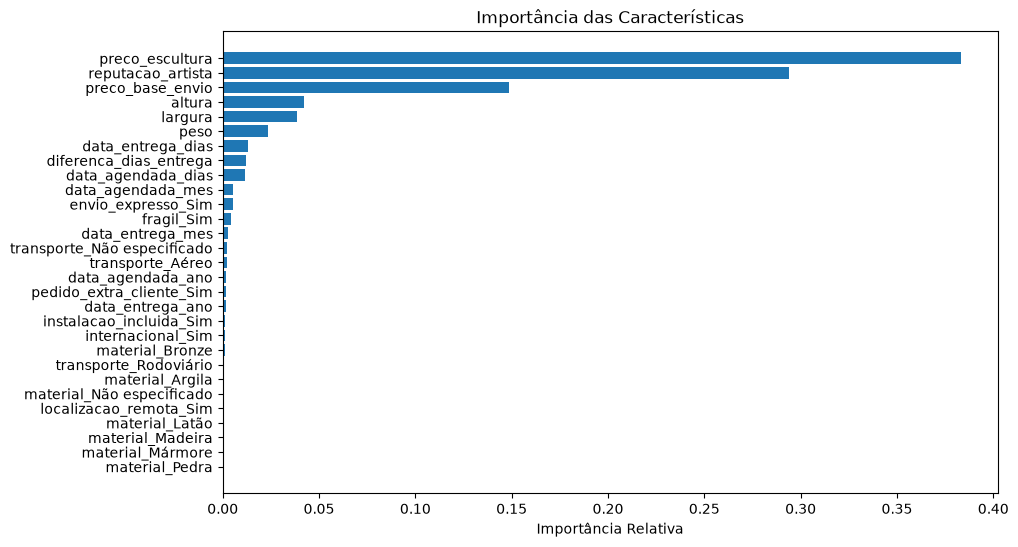

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

features_importancias = pd.DataFrame({'Feature': dtr.feature_names_in_,
                                      'Importância': dtr.feature_importances_}).sort_values(by='Importância', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(features_importancias['Feature'], features_importancias['Importância'])
plt.xlabel('Importância Relativa')
plt.title('Importância das Características')

plt.show()

# Evitando o overfitting com a otimização

![](https://github.com/Mirlaa/regressao-arvores/blob/main/imagens-projeto/imagem--2.png?raw=true)

In [148]:
param_grid = {
    'max_depth': [6, 8, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 15],
    'max_leaf_nodes': [None, 100, 500]
}

In [149]:
from sklearn.model_selection import GridSearchCV

grid_search_dtr = GridSearchCV(dtr, param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_search_dtr.fit(X_treino,y_treino)

dtr_otimizado = grid_search_dtr.best_estimator_

print('Melhores parâmetros:', grid_search_dtr.best_params_)

Melhores parâmetros: {'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, dtr_otimizado.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, dtr_otimizado.predict(X_treino)))
print('RMSE:', root_mean_squared_error(y_treino, dtr_otimizado.predict(X_treino)))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, dtr_otimizado.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, dtr_otimizado.predict(X_teste)))
print('RMSE:', root_mean_squared_error(y_teste, dtr_otimizado.predict(X_teste)))


Métricas conjunto de treino:
R²: 0.8709496124958277
MAE: 473.7084817751579
RMSE: 980.4175958553703


Métricas conjunto de teste:
R²: 0.7539366877133971
MAE: 586.9786990247474
RMSE: 1315.2024908853869


**VAMOS COMPARAR**

![](https://github.com/Mirlaa/regressao-arvores/blob/main/imagens-projeto/imagem-3.png?raw=true)

In [151]:
from sklearn.model_selection import cross_validate, KFold

cv_estrategia = KFold(n_splits=3, shuffle=True, random_state=45)

resultados = cross_validate(dtr_otimizado,X,y,scoring='neg_mean_squared_error', cv= cv_estrategia,
                            return_train_score=True)

In [152]:
treino_rmse = np.sqrt(-resultados['train_score'])
teste_rmse = np.sqrt(-resultados['test_score'])

print("Treino RMSE em cada fold:", treino_rmse)
print("Teste RMSE em cada fold:", teste_rmse)
print("\nMédia do RMSE no treino:", treino_rmse.mean())
print("Média do RMSE no teste:", teste_rmse.mean())

Treino RMSE em cada fold: [1061.33787095  985.34242721 1023.82861998]
Teste RMSE em cada fold: [1359.22040707 1469.19123426 1424.79371964]

Média do RMSE no treino: 1023.5029727125925
Média do RMSE no teste: 1417.7351203213384


# Implementando uma Floresta Aleatória

In [153]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor (n_estimators=100, random_state=45, oob_score=True)
rfr.fit(X_treino,y_treino)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",45
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node s

In [155]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, rfr.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, rfr.predict(X_treino)))
print('RMSE:', root_mean_squared_error(y_treino, rfr.predict(X_treino)))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, rfr.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, rfr.predict(X_teste)))
print('RMSE:', root_mean_squared_error(y_teste, rfr.predict(X_teste)))

print('\n\nPrevisão OOB R²:', rfr.oob_score_)


Métricas conjunto de treino:
R²: 0.977673863082759
MAE: 183.20306414962178
RMSE: 407.79155949769375


Métricas conjunto de teste:
R²: 0.8251064459880812
MAE: 457.94058770996656
RMSE: 1108.8073379526115


Previsão OOB R²: 0.8304545778759526


**VAMOS COMPARAR**

![](https://github.com/Mirlaa/regressao-arvores/blob/main/imagens-projeto/imagem-4.png?raw=true)

In [156]:
cv_estrategia = KFold(n_splits=3, shuffle=True, random_state=45)

resultados = cross_validate(rfr,X,y,scoring='neg_mean_squared_error', cv= cv_estrategia,
                            return_train_score=True)

treino_rmse = np.sqrt(-resultados['train_score'])
teste_rmse = np.sqrt(-resultados['test_score'])

print("Média do RMSE no treino:", treino_rmse.mean())
print("Média do RMSE no teste:", teste_rmse.mean())

Média do RMSE no treino: 428.9164790278148
Média do RMSE no teste: 1146.9846581405075


# Buscando a otimização da Floresta Aleatória

In [157]:
param_grid = {
    'max_depth': [None, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 5],
    'max_leaf_nodes':  [400, 550]
}

In [158]:
rf = RandomForestRegressor(random_state=45)

grid_search_rfr = GridSearchCV(rf, param_grid, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
grid_search_rfr.fit(X_treino,y_treino)

rfr_otimizado = grid_search_rfr.best_estimator_

print('Melhores parâmetros:', grid_search_rfr.best_params_)

Melhores parâmetros: {'max_depth': None, 'max_leaf_nodes': 550, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print('Métricas conjunto de treino:')
print('R²:', r2_score(y_treino, rfr_otimizado.predict(X_treino)))
print('MAE:', mean_absolute_error(y_treino, rfr_otimizado.predict(X_treino)))
print('RMSE:', root_mean_squared_error(y_treino, rfr_otimizado.predict(X_treino)))

print('\n\nMétricas conjunto de teste:')
print('R²:', r2_score(y_teste, rfr_otimizado.predict(X_teste)))
print('MAE:', mean_absolute_error(y_teste, rfr_otimizado.predict(X_teste)))
print('RMSE:', root_mean_squared_error(y_teste, rfr_otimizado.predict(X_teste)))


Métricas conjunto de treino:
R²: 0.966369144534208
MAE: 223.24720654660322
RMSE: 500.49575448582226


Métricas conjunto de teste:
R²: 0.8259869845358565
MAE: 455.1161634232036
RMSE: 1106.0125533789828


**VAMOS COMPARAR**

![](https://github.com/Mirlaa/regressao-arvores/blob/main/imagens-projeto/imagem-5.png?raw=true)

In [162]:
cv_estrategia = KFold(n_splits=3, shuffle=True, random_state=45)

resultados = cross_validate(rfr_otimizado,X,y,scoring='neg_mean_squared_error', cv= cv_estrategia,
                            return_train_score=True)

treino_rmse = np.sqrt(-resultados['train_score'])
teste_rmse = np.sqrt(-resultados['test_score'])

print("Média do RMSE no treino:", treino_rmse.mean())
print("Média do RMSE no teste:", teste_rmse.mean())

Média do RMSE no treino: 527.4397761558678
Média do RMSE no teste: 1143.846745993551


In [163]:
novos_dados = pd.read_csv(url_teste)

custos = rfr_otimizado.predict(novos_dados)

novos_dados['custo'] = custos
novos_dados

,reputacao_artista,altura,largura,peso,preco_escultura,preco_base_envio,diferenca_dias_entrega,data_agendada_dias,data_agendada_mes,data_agendada_ano,...,material_Bronze,material_Latão,material_Madeira,material_Mármore,material_Não especificado,material_Pedra,transporte_Aéreo,transporte_Não especificado,transporte_Rodoviário,custo
0,0.67,2.1336,1.2192,48.987936,36.3300,73.2900,0,2,5,2020,...,False,False,False,False,False,False,False,False,True,1160.319118
1,0.61,1.8288,1.5240,43.998424,22.2075,71.5050,2,4,1,2022,...,False,False,False,False,False,False,True,False,False,1114.794811
2,0.14,4.5720,2.4384,343.369144,32.9700,124.8975,3,14,9,2021,...,False,False,False,False,False,False,False,False,True,1009.792168
3,0.63,3.0480,1.2192,758.859416,23.0475,93.6075,-1,3,12,2021,...,False,False,False,True,False,False,False,False,True,1553.565361
4,0.34,9.7536,1.8288,505.755080,34.9125,119.7000,4,3,2,2022,...,False,False,False,False,False,False,True,False,False,1440.866779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,0.00,2.1336,1.5240,736.179816,22.6275,113.1375,-3,14,11,2021,...,False,False,False,True,False,False,True,False,False,963.489644
1430,0.10,3.6576,1.8288,390.996304,27.7725,80.6400,0,9,12,2019,...,True,False,False,False,False,False,False,False,True,726.439325
1431,0.20,1.2192,1.2192,9.071840,31.0800,105.5250,4,6,3,2022,...,False,False,False,False,False,False,False,False,True,849.624140
1432,0.22,9.7536,2.4384,488.972176,27.7725,112.8225,-3,21,2,2023,...,False,False,False,False,False,False,False,False,False,1077.269370


In [164]:
novos_dados.to_csv('Precos_entregas.csv',index=False)

In [167]:
import os
import pandas as pd
from sklearn.metrics import root_mean_squared_error

print("=== INICIANDO CHECK-UP DO PROJETO ===\n")

# 1. VALIDAÇÃO DOS ARQUIVOS
arquivos = [
    'Dados/entregas.csv', 
    'Dados/teste_entregas.csv', 
    'Dados/Precos_entregas.csv'
]
arquivos_ok = True

for arq in arquivos:
    if os.path.exists(arq):
        print(f"✔️ Arquivo encontrado: {arq}")
    else:
        print(f"❌ ERRO: Arquivo não encontrado -> {arq}")
        arquivos_ok = False

# 2. VALIDAÇÃO DOS MODELOS E VARIÁVEIS
if arquivos_ok:
    print("\n--- Verificando Modelos e Variáveis na Memória ---")
    
    # Dicionário com os objetos que devem existir
    objetos_obrigatorios = {
        'X_treino': 'Variável de treino X',
        'y_treino': 'Variável de treino y',
        'X_teste': 'Variável de teste X',
        'y_teste': 'Variável de teste y',
        'dtr': 'Modelo DecisionTreeRegressor base',
        'dtr_otimizado': 'Modelo DecisionTreeRegressor otimizado',
        'rfr': 'Modelo RandomForestRegressor base',
        'rfr_otimizado': 'Modelo RandomForestRegressor otimizado'
    }
    
    erros_memoria = 0
    for nome_obj, descricao in objetos_obrigatorios.items():
        if nome_obj in globals():
            print(f"✔️ {descricao} ('{nome_obj}') carregado com sucesso.")
        else:
            print(f"⚠️ Alerta: '{nome_obj}' ({descricao}) não foi encontrado na memória.")
            erros_memoria += 1
            
    # 3. TESTE DE PREVISÃO DE SEGURANÇA (Evitando erro de TypeError antigo)
    if erros_memoria == 0:
        print("\n--- Testando cálculo de RMSE moderno (Sem 'squared=False') ---")
        try:
            teste_rmse = root_mean_squared_error(y_teste, rfr_otimizado.predict(X_teste))
            print(f"✔️ Teste executado 100%! Último RMSE calculado: {teste_rmse:.4f}")
            print("\n🎉 PARABÉNS! Tudo no projeto está funcionando perfeitamente!")
        except Exception as e:
            print(f"❌ Erro ao tentar rodar a previsão final: {e}")
    else:
        print(f"\n⚠️ O código está atualizado, mas faltam {erros_memoria} variáveis na memória.")
        print("Dica: No menu superior do VS Code, clique em 'Run All' (Executar Tudo) para rodar o notebook inteiro em ordem.")
else:
    print("\n❌ Corrija a posição ou os nomes dos arquivos antes de prosseguir.")


=== INICIANDO CHECK-UP DO PROJETO ===

✔️ Arquivo encontrado: Dados/entregas.csv
✔️ Arquivo encontrado: Dados/teste_entregas.csv
✔️ Arquivo encontrado: Dados/Precos_entregas.csv

--- Verificando Modelos e Variáveis na Memória ---
✔️ Variável de treino X ('X_treino') carregado com sucesso.
✔️ Variável de treino y ('y_treino') carregado com sucesso.
✔️ Variável de teste X ('X_teste') carregado com sucesso.
✔️ Variável de teste y ('y_teste') carregado com sucesso.
✔️ Modelo DecisionTreeRegressor base ('dtr') carregado com sucesso.
✔️ Modelo DecisionTreeRegressor otimizado ('dtr_otimizado') carregado com sucesso.
✔️ Modelo RandomForestRegressor base ('rfr') carregado com sucesso.
✔️ Modelo RandomForestRegressor otimizado ('rfr_otimizado') carregado com sucesso.

--- Testando cálculo de RMSE moderno (Sem 'squared=False') ---
✔️ Teste executado 100%! Último RMSE calculado: 1106.0126

🎉 PARABÉNS! Tudo no projeto está funcionando perfeitamente!
